In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.spatial.distance as ssd
import datetime as dt
import meteostat
import scipy.stats

In [3]:
transcriptome = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/plate1_5_tpm_normalized.csv",
    index_col=0,
)
rows_to_drop_expression_data = [
    "A2450525897_n01_undetermined",
    "A2449446903_n01_undetermined",
    "B250508004_n01_undetermined",
    "B2449500127_n01_undetermined",
]
transcriptome = transcriptome.drop(index=rows_to_drop_expression_data)
transcriptome = transcriptome.sort_index()
metadata = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Plates_1_to_5_metadata_merged_luke.csv",
    index_col=0,
)
metadata = metadata.drop(
    columns=[
        "arb.sort",
        "sample-id",
        "Ambiguous Unstranded",
        "Ambiguous Forward",
        "Multimapping",
        "Unmapped Over Mapped",
    ]
)
metadata["Date and Time"] = metadata["date"] + " " + metadata["time"]
luke_time_data_format = "%-m/%-d/%y %-H:%-M"
metadata["Date and Time"] = pd.to_datetime(
    metadata["Date and Time"], format=luke_time_data_format
)


## Get plate 5 samples and remove what they replaced from the metadata to avoid duplicates
plate_5_replacements = metadata.loc[metadata["rnaprepplate"] == "LICRNA_05"]
non_plate_5_samples = metadata.loc[metadata["rnaprepplate"] != "LICRNA_05"]
replaced_samples = non_plate_5_samples.loc[
    non_plate_5_samples["sampID"].isin(plate_5_replacements["sampID"])
]
trimmed_metadata = metadata.drop(index=replaced_samples.index)
### get duplicates and drop the one with higher total genes, so that we can drop everything from the main list
double_duplicates = (
    trimmed_metadata.loc[
        trimmed_metadata.duplicated(
            subset="sampID",
            keep=False,
        )
    ]
    .sort_values(by="Total Reads")
    .drop_duplicates(subset="sampID", keep="first")
)
trimmed_metadata = trimmed_metadata.drop(index=double_duplicates.index)
trimmed_metadata
trimmed_transcriptome = transcriptome.loc[trimmed_metadata.index]
trimmed_transcriptome

,AT1G01010,AT1G01020,AT1G03987,AT1G01030,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G03997,AT1G01060,...,ArthCt124,ArthCr088,ArthCt112,ArthCp088,ArthCp086,ArthCt118,ArthCp083,ArthCt111,ArthCp084,ArthCp085
filename,,,,,,,,,,,,,,,,,,,,,
A2450525897_n01_LICRNA01_A01,4.944011,1.397952,0.0,5.994827,5.876072,0.0,0.0,58.062147,0.0,15.150509,...,0.000000,13.256631,0.000000,0.938539,0.0,0.0,0.956942,0.0,0.000000,1.597223
A2450525897_n01_LICRNA01_B01,2.911492,4.379655,0.0,2.665837,3.261267,0.0,0.0,57.934612,0.0,10.439273,...,0.000000,13.734068,0.000000,0.350043,0.0,0.0,0.166556,0.0,0.000000,2.184266
A2450525897_n01_LICRNA01_C01,6.270921,9.657724,0.0,0.000000,4.158376,0.0,0.0,38.161651,0.0,10.623477,...,34.304262,31.001035,0.000000,0.000000,0.0,0.0,0.051248,0.0,0.000000,0.855379
A2450525897_n01_LICRNA01_E01,3.690795,5.635420,0.0,3.786748,2.141076,0.0,0.0,37.996762,0.0,8.530523,...,0.000000,9.676399,0.000000,0.000000,0.0,0.0,0.142875,0.0,0.000000,1.987260
A2450525897_n01_LICRNA01_F01,2.781737,8.695001,0.0,2.016710,8.565957,0.0,0.0,64.854957,0.0,16.845214,...,0.000000,67.280011,0.000000,0.000000,0.0,0.0,0.496000,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2534491401_n01_LICRNA05_D12,0.000000,8.339930,0.0,7.860235,3.199519,0.0,0.0,39.201659,0.0,1.057777,...,0.000000,4.602930,22.529946,1.333133,0.0,0.0,0.036247,0.0,4.867353,5.293749
A2534491401_n01_LICRNA05_E12,0.000000,1.692107,0.0,1.577446,3.055581,0.0,0.0,29.564231,0.0,12.872063,...,0.000000,6.899039,1.605254,3.951394,0.0,0.0,0.839348,0.0,0.000000,3.222183
A2534491401_n01_LICRNA05_F12,0.641335,5.972190,0.0,1.641699,5.632121,0.0,0.0,48.940407,0.0,24.612749,...,0.000000,7.502750,0.000000,1.799150,0.0,0.0,0.000000,0.0,0.000000,0.145801


In [4]:
trimmed_metadata["Experiment Type"].unique()

array(['Long Term', 'Circadian Experiment 1', 'Circadian Experiment 2'],
      dtype=object)

In [5]:
plant_microbiome = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Microbiome/lic2024_16S_rab.csv"
)
plant_microbiome.head()

,Sample,sample.type,timepoint,date,time,platename,daysincestart,plantID,Kingdom,Phylum,Class,Order,Family,Genus,Species,AbundR100
0,LIC522,plant,c1_t11,2/11/24,12:00,LICCIRC_02,102,LIC522,d__Bacteria,Pseudomonadota,Gammaproteobacteria,Pseudomonadales_A_650611,Pseudomonadaceae,Pseudomonas_E_647464,Pseudomonas_E_647464 viridiflava,79.1
1,LIC063,plant,t06,11/28/23,8:00,LIC_01,27,LIC063,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Sphingomonadales,Sphingomonadaceae_486827,Sphingomonas_L_486704,Sphingomonas_L_486704 sp000786205,66.1
2,LIC159,plant,t14,1/23/24,8:00,LIC_02,83,LIC159,d__Bacteria,Cyanobacteriota,Cyanobacteriia,Cyanobacteriales,Coleofasciculaceae,Caldora,Caldora sp010672925,60.5
3,LIC452,plant,c1_t06,2/10/24,16:00,LICCIRC_01,101,LIC452,d__Bacteria,Pseudomonadota,Gammaproteobacteria,Burkholderiales,Burkholderiaceae_A_595421,Massilia_574544,Massilia atriviolacea,59.8
4,LIC306,plant,t26,3/8/24,8:00,LIC_04,128,LIC306,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Sphingomonadales,Sphingomonadaceae_486827,Sphingomonas_L_486704,Sphingomonas_L_486704 sp000786205,57.2


In [6]:
def pairwise_braycurtis_long(vectors, labels):
    """
    Calculate Bray-Curtis distance between all pairs of vectors.

    Parameters:
    vectors : array-like
        2D array where each row is a sample vector
    labels : list, optional
        Labels for each vector. If None, uses integer indices.

    Returns:
    pd.DataFrame
        Long-format DataFrame with columns: sample1, sample2, distance
    """
    vectors = np.array(vectors)
    n = len(vectors)

    results = []
    for i in range(n):
        for j in range(i + 1, n):
            dist = ssd.braycurtis(vectors[i], vectors[j])
            results.append(
                {"sample1": labels[i], "sample2": labels[j], "distance": dist}
            )

    return pd.DataFrame(results)

In [7]:
# Get long term samples that are loaded in metadata
long_term_metadata = trimmed_metadata.loc[
    trimmed_metadata["Experiment Type"] == "Long Term"
]
long_term_samples_list = long_term_metadata["sampID"].dropna().unique().tolist()

# Filter microbiome data to only those samples
plant_microbiome_lt = plant_microbiome.loc[
    plant_microbiome["Sample"].isin(long_term_samples_list)
]

# Group by Genus to sum abundances per genus (similar to the 'table_with_id.groupby("Genus").sum()' in the soil notebook)
# For plant_microbiome, we can just pivot to get a matrix: Genus x Sample
plant_genus_abundance = plant_microbiome_lt.pivot_table(
    index="Genus", columns="Sample", values="AbundR100", aggfunc="sum", fill_value=0
)
plant_genus_abundance.head()

Sample,LIC001,LIC002,LIC003,LIC004,LIC005,LIC006,LIC007,LIC008,LIC013,LIC014,...,LIC355,LIC356,LIC361,LIC362,LIC363,LIC364,LIC365,LIC366,LIC367,LIC368
Genus,,,,,,,,,,,,,,,,,,,,,
Abditibacterium,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Actinoallomurus,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Actinocorallia,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Actinomycetospora,0.6,0.0,0.0,1.8,0.6,0.0,0.0,0.0,0.0,0.0,...,0.6,0.0,0.0,0.0,0.0,0.5,0.0,0.0,3.4,1.9
Actinoplanes,1.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,...,0.6,0.5,0.0,0.0,0.6,0.0,0.0,0.0,0.5,1.4


In [8]:
all_distances = []

for timepoint in long_term_metadata["timepoint"].unique():
    # Get metadata for samples at this timepoint
    tp_metadata = long_term_metadata.loc[long_term_metadata["timepoint"] == timepoint]
    sample_ids = tp_metadata["sampID"].tolist()

    # Filter to only the sample IDs that are also in our microbiome matrix
    sample_ids = [s for s in sample_ids if s in plant_genus_abundance.columns]

    if (
        len(sample_ids) > 1
    ):  # Compute stats if we have multiple samples to do pairwise comparison
        # Get abundance vectors for these samples
        vectors = plant_genus_abundance[sample_ids].T.values
        labels = sample_ids

        # Calculate pairwise distances
        tp_distances = pairwise_braycurtis_long(vectors, labels)
        tp_distances["timepoint"] = timepoint

        # Add date/time info
        tp_distances["date"] = tp_metadata["date"].iloc[0]
        tp_distances["time"] = tp_metadata["time"].iloc[0]
        tp_distances["Date and Time"] = tp_metadata["Date and Time"].iloc[0]

        all_distances.append(tp_distances)

# Concatenate all results
distances_df = pd.concat(all_distances, ignore_index=True)
distances_df.head()

,sample1,sample2,distance,timepoint,date,time,Date and Time
0,LIC001,LIC002,0.566293,t01,11/1/23,8:00,2023-11-01 08:00:00
1,LIC001,LIC003,0.394191,t01,11/1/23,8:00,2023-11-01 08:00:00
2,LIC001,LIC005,0.543593,t01,11/1/23,8:00,2023-11-01 08:00:00
3,LIC001,LIC006,0.581829,t01,11/1/23,8:00,2023-11-01 08:00:00
4,LIC001,LIC008,0.455522,t01,11/1/23,8:00,2023-11-01 08:00:00


In [9]:
start_time = dt.datetime(2023, 10, 1)
end_time = dt.datetime(2024, 4, 30)
luke_apt_point = meteostat.Point(40.73005, -73.99450)
luke_hourly_data = meteostat.Hourly(luke_apt_point, start_time, end_time).fetch()

luke_rain_events = luke_hourly_data.loc[luke_hourly_data["prcp"] >= 1]
luke_rain_events.index = pd.to_datetime(luke_rain_events.index)

list_of_time_since_rain = []
for time in distances_df["Date and Time"].to_list():
    time_since_all_rain = time - luke_rain_events.index
    rain_events_in_past = luke_rain_events.loc[
        time_since_all_rain >= dt.timedelta(seconds=0)
    ]
    time_of_last_rain = rain_events_in_past.index.max()
    time_since_last_rain = time - time_of_last_rain
    list_of_time_since_rain.append(time_since_last_rain)

distances_df["Time Since Rain"] = list_of_time_since_rain
distances_df

,sample1,sample2,distance,timepoint,date,time,Date and Time,Time Since Rain
0,LIC001,LIC002,0.566293,t01,11/1/23,8:00,2023-11-01 08:00:00,2 days 15:00:00
1,LIC001,LIC003,0.394191,t01,11/1/23,8:00,2023-11-01 08:00:00,2 days 15:00:00
2,LIC001,LIC005,0.543593,t01,11/1/23,8:00,2023-11-01 08:00:00,2 days 15:00:00
3,LIC001,LIC006,0.581829,t01,11/1/23,8:00,2023-11-01 08:00:00,2 days 15:00:00
4,LIC001,LIC008,0.455522,t01,11/1/23,8:00,2023-11-01 08:00:00,2 days 15:00:00
...,...,...,...,...,...,...,...,...
765,LIC365,LIC367,0.503134,t08,12/5/23,8:00,2023-12-05 08:00:00,1 days 13:00:00
766,LIC365,LIC368,0.519362,t08,12/5/23,8:00,2023-12-05 08:00:00,1 days 13:00:00
767,LIC366,LIC367,0.567749,t08,12/5/23,8:00,2023-12-05 08:00:00,1 days 13:00:00
768,LIC366,LIC368,0.488528,t08,12/5/23,8:00,2023-12-05 08:00:00,1 days 13:00:00


In [10]:
plot_df = (
    distances_df[["distance", "timepoint", "Time Since Rain"]]
    .groupby("timepoint")
    .mean()
).reset_index()

# Drop any NaN distances if present
plot_df = plot_df.dropna(subset=["distance"])
plot_df

,timepoint,distance,Time Since Rain
0,t01,0.548049,2 days 15:00:00
1,t02,0.564528,8 days 15:00:00
2,t03,0.479859,4 days 12:00:00
3,t04,0.493277,7 days 12:00:00
4,t05,0.570119,11 days 12:00:00
5,t06,0.501818,1 days 02:00:00
6,t07,0.559067,4 days 02:00:00
7,t08,0.489641,1 days 13:00:00
8,t09,0.520243,4 days 13:00:00
9,t10,0.564758,0 days 23:00:00


In [11]:
scipy.stats.pearsonr(
    plot_df["Time Since Rain"].dt.total_seconds() / 3600,
    plot_df["distance"],
)

PearsonRResult(statistic=np.float64(0.2887396435958371), pvalue=np.float64(0.13618293766751347))

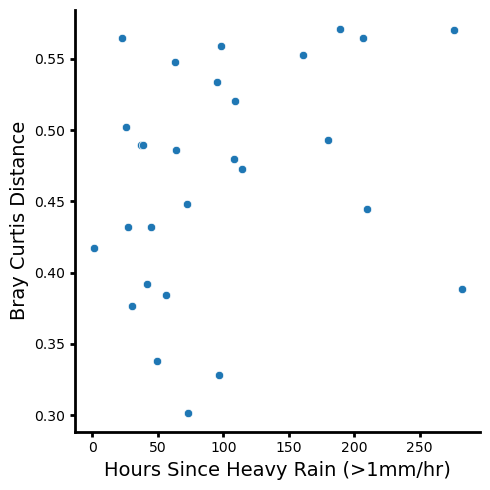

In [12]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
ax = sns.scatterplot(
    data=plot_df,
    x=plot_df["Time Since Rain"].dt.total_seconds() / 3600,
    y="distance",
    palette="viridis",
)
plt.xlabel("Hours Since Heavy Rain (>1mm/hr)", fontsize=14)
plt.ylabel("Bray Curtis Distance", fontsize=14)
sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

Pearson r: 0.122, p-value: 5.351e-01


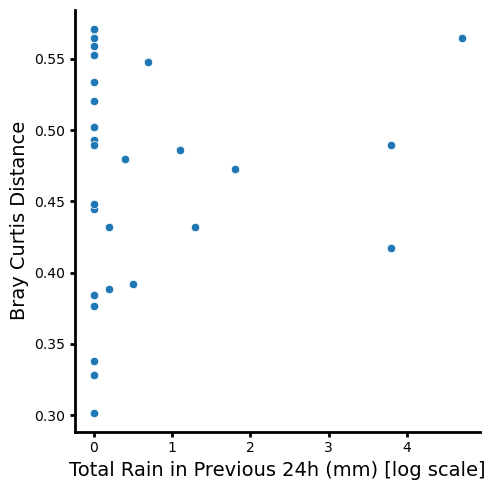

In [13]:
list_of_rain_prev_24h = []
for time in distances_df["Date and Time"].to_list():
    time_24h_ago = time - dt.timedelta(hours=24)
    rain_in_window = luke_hourly_data.loc[
        (luke_hourly_data.index > time_24h_ago) & (luke_hourly_data.index <= time)
    ]
    total_rain = rain_in_window["prcp"].sum()
    list_of_rain_prev_24h.append(total_rain)

distances_df["Rain Previous 24h"] = list_of_rain_prev_24h

plot_df_24h = (
    distances_df[["distance", "timepoint", "Rain Previous 24h"]]
    .groupby("timepoint")
    .mean()
).reset_index()

plot_df_24h = plot_df_24h.dropna(subset=["distance"])

# We may encounter zeroes in the rain data which cannot be log scaled easily
# To avoid taking log10(0), we will plot the x-axis on a log base 10 scale but we should probably use a symlog or pseudo-log.
# However, usually just ax.set_xscale("log") works well for non-zero data, or "symlog" to handle zeroes.
# Let's use symlog to gracefully handle samples with 0 total rain.

corr, pval = scipy.stats.pearsonr(
    plot_df_24h["Rain Previous 24h"],
    plot_df_24h["distance"],
)
print(f"Pearson r: {corr:.3f}, p-value: {pval:.3e}")

fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
ax = sns.scatterplot(
    data=plot_df_24h,
    x="Rain Previous 24h",
    y="distance",
    palette="viridis",
)
plt.xlabel("Total Rain in Previous 24h (mm) [log scale]", fontsize=14)
plt.ylabel("Bray Curtis Distance", fontsize=14)
# ax.set_xscale("symlog") # symlog handles 0 values well
sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

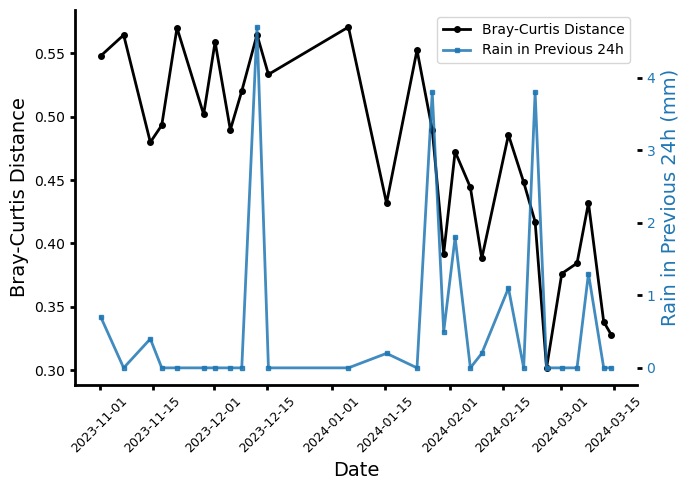

In [14]:
# Plot mean Bray-Curtis distance over time alongside total rainfall in the previous 24 hours.
bray_curtis_over_time = (
    distances_df.groupby("timepoint", as_index=False)
    .agg(
        {
            "Date and Time": "first",
            "distance": "mean",
            "Rain Previous 24h": "mean",
        }
    )
    .dropna(subset=["Date and Time", "distance", "Rain Previous 24h"])
    .sort_values("Date and Time")
)
bray_curtis_over_time["Date and Time"] = pd.to_datetime(
    bray_curtis_over_time["Date and Time"]
)

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor("white")
ax.plot(
    bray_curtis_over_time["Date and Time"],
    bray_curtis_over_time["distance"],
    color="black",
    linewidth=2,
    marker="o",
    markersize=4,
    label="Bray-Curtis Distance",
)
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Bray-Curtis Distance", fontsize=14, color="black")
ax.tick_params(axis="x", width=2, labelsize=9, rotation=45)
ax.tick_params(axis="y", width=2, labelsize=10, labelcolor="black")

ax_rain = ax.twinx()
ax_rain.plot(
    bray_curtis_over_time["Date and Time"],
    bray_curtis_over_time["Rain Previous 24h"],
    color="tab:blue",
    linewidth=2,
    marker="s",
    markersize=3.5,
    alpha=0.85,
    label="Rain in Previous 24h",
)
ax_rain.set_ylabel("Rain in Previous 24h (mm)", fontsize=14, color="tab:blue")
ax_rain.tick_params(axis="y", width=2, labelsize=10, labelcolor="tab:blue")

sns.despine(ax=ax)
sns.despine(ax=ax_rain, left=True)
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax_rain.spines["right"].set_color("tab:blue")
ax_rain.spines["right"].set_linewidth(2)

lines_left, labels_left = ax.get_legend_handles_labels()
lines_right, labels_right = ax_rain.get_legend_handles_labels()
ax.legend(lines_left + lines_right, labels_left + labels_right, loc="upper right")
plt.tight_layout()
plt.show()

## Do specific genera track heat, temperature swings, rain, or drought?

The Bray-Curtis analysis above asks whether the community as a whole is more variable
after a weather event. This section asks which *individual genera* move with the weather.

Design:

- **Unit of analysis is the timepoint (n = 28), not the plant.** All 8 plants sampled on a
  given morning share the same weather, so per-plant abundances are pseudoreplicates for a
  weather question. Genus abundances are renormalized per plant and then averaged within
  each timepoint.
- **Genera tested**: present in >= 25% of plants and >= 0.1% mean relative abundance, which
  keeps ~30 genera covering >90% of the community and holds the multiple-testing burden down.
- **Statistic**: Spearman rho (monotone, robust to the zero-inflated abundance distribution),
  with Benjamini-Hochberg FDR computed within each weather variable.
- **Two robustness checks**, because a 4.5-month Nov->Mar series has both a seasonal trend
  and temporal autocorrelation: (1) a *season-adjusted* partial Spearman that removes
  day-of-experiment, and (2) a circular-shift permutation test that preserves each genus's
  own autocorrelation.

In [15]:
# Genus x timepoint abundance table.
# Sample columns sum to ~87 rather than 100 (reads with no genus assignment are absent),
# so renormalize each plant before averaging plants within a timepoint.
genus_rel_abundance = plant_genus_abundance / plant_genus_abundance.sum(axis=0) * 100

sample_to_timepoint = (
    plant_microbiome_lt.drop_duplicates("Sample").set_index("Sample")["timepoint"]
)
timepoint_times = (
    long_term_metadata.dropna(subset=["sampID"])
    .drop_duplicates(subset="timepoint")
    .set_index("timepoint")[["Date and Time", "daysincestart"]]
    .sort_values("Date and Time")
)
timepoint_times = timepoint_times.loc[
    timepoint_times.index.isin(sample_to_timepoint.unique())
]

genus_by_timepoint = (
    genus_rel_abundance.T.join(sample_to_timepoint)
    .groupby("timepoint")
    .mean()
    .reindex(timepoint_times.index)
)

# Only test genera detectable often enough for a rank correlation to mean anything.
genus_prevalence = (genus_rel_abundance > 0).mean(axis=1)
genus_mean_abundance = genus_rel_abundance.mean(axis=1)
genera_to_test = genus_prevalence[
    (genus_prevalence >= 0.25) & (genus_mean_abundance >= 0.1)
].index.tolist()

print(
    f"{genus_by_timepoint.shape[0]} timepoints x {len(sample_to_timepoint)} plants; "
    f"testing {len(genera_to_test)} of {genus_rel_abundance.shape[0]} genera "
    f"({genus_mean_abundance[genera_to_test].sum():.0f}% of the mean community)"
)
genus_by_timepoint[genera_to_test].head()

28 timepoints x 222 plants; testing 32 of 137 genera (94% of the mean community)


,Actinomycetospora,Actinoplanes,Agrobacterium,Aureimonas_A_501549,Blastococcus,Brevundimonas,Caldora,Chryseobacterium_A_796612,Flavobacterium,Friedmanniella,...,Pseudoduganella_570666,Pseudomonas_B_650453,Pseudomonas_E_647464,Ramlibacter_588642,Rathayibacter,Rhodoferax_C,Rugamonas_570800,Sphingomonas_L_486704,Telluria_573210,Variovorax
timepoint,,,,,,,,,,,,,,,,,,,,,
t01,0.427458,0.167072,0.000000,1.082062,0.774922,1.985459,0.000000,0.301619,6.051652,1.227744,...,1.134616,4.288696,2.406995,1.104084,0.071510,4.085961,0.258761,31.301386,1.938383,2.684186
t02,0.691504,0.871256,0.292296,0.097439,1.713782,0.179060,0.000000,0.158827,2.098249,1.190880,...,0.612945,2.557980,2.813016,0.000000,0.070304,2.824648,0.304171,38.295041,3.583043,0.880656
t03,0.669301,0.510925,0.409520,0.088548,0.315703,0.222438,0.138276,2.982390,5.001717,1.196878,...,2.303834,2.803106,1.867015,0.000000,0.787949,4.524096,0.482711,34.014013,1.560591,2.070572
t04,0.340157,0.000000,0.430556,0.415547,0.992951,0.000000,0.227654,3.534880,2.103234,1.440533,...,0.435864,1.884407,4.341772,0.000000,0.520528,3.518599,0.956050,32.859174,1.007984,1.154357
t05,0.397040,0.681275,0.704073,0.770633,0.751186,1.170608,0.000000,9.429485,0.211353,2.084968,...,0.148158,2.654603,3.097576,0.000000,0.070146,2.738457,0.164457,24.707187,0.979129,0.744705


In [16]:
# Weather features for every sampling timepoint: heat, temperature swings, rain, drought.
# Refetch with a 35-day lead-in so the 30-day lookback windows are complete.
weather_start = timepoint_times["Date and Time"].min() - dt.timedelta(days=35)
weather_end = timepoint_times["Date and Time"].max() + dt.timedelta(days=1)
weather_hourly = meteostat.Hourly(luke_apt_point, weather_start, weather_end).fetch()


def weather_window(sample_time, hours_back, hours_forward=0):
    """Hourly weather in (sample_time - hours_back, sample_time - hours_forward]."""
    return weather_hourly.loc[
        (weather_hourly.index > sample_time - dt.timedelta(hours=hours_back))
        & (weather_hourly.index <= sample_time - dt.timedelta(hours=hours_forward))
    ]


heavy_rain_events = weather_hourly.loc[weather_hourly["prcp"] >= 1]

weather_rows = []
for timepoint, row in timepoint_times.iterrows():
    sample_time = row["Date and Time"]
    last_24h = weather_window(sample_time, 24)
    prev_24h = weather_window(sample_time, 48, 24)  # the 24h before that
    last_72h = weather_window(sample_time, 72)
    last_7d = weather_window(sample_time, 24 * 7)
    last_14d = weather_window(sample_time, 24 * 14)
    last_30d = weather_window(sample_time, 24 * 30)

    rain_before = heavy_rain_events.loc[heavy_rain_events.index <= sample_time]
    hours_since_rain = (
        (sample_time - rain_before.index.max()).total_seconds() / 3600
        if len(rain_before)
        else np.nan
    )
    # Length of the unbroken dry spell (<0.2 mm/h) ending at the sampling time.
    precip_history = weather_hourly.loc[
        weather_hourly.index <= sample_time, "prcp"
    ].fillna(0)
    wet_hours = np.flatnonzero(precip_history.values >= 0.2)
    dry_streak_hours = (
        len(precip_history) - 1 - wet_hours[-1] if len(wet_hours) else len(precip_history)
    )

    weather_rows.append(
        {
            "timepoint": timepoint,
            "Mean temp 24h (C)": last_24h["temp"].mean(),
            "Max temp 24h (C)": last_24h["temp"].max(),
            "Min temp 24h (C)": last_24h["temp"].min(),
            "Mean temp 7d (C)": last_7d["temp"].mean(),
            "Temp anomaly vs 30d (C)": last_24h["temp"].mean() - last_30d["temp"].mean(),
            "Diurnal temp range (C)": last_24h["temp"].max() - last_24h["temp"].min(),
            "Temp change vs prev 24h (C)": last_24h["temp"].mean() - prev_24h["temp"].mean(),
            "Temp change vs 7d (C)": last_24h["temp"].mean() - last_7d["temp"].mean(),
            "Rain 24h (mm)": last_24h["prcp"].sum(),
            "Rain 72h (mm)": last_72h["prcp"].sum(),
            "Rain 7d (mm)": last_7d["prcp"].sum(),
            "Rain 14d (mm)": last_14d["prcp"].sum(),
            "Hours since heavy rain": hours_since_rain,
            "Dry streak (h)": dry_streak_hours,
            "Mean humidity 24h (%)": last_24h["rhum"].mean(),
        }
    )

weather_features = pd.DataFrame(weather_rows).set_index("timepoint")

# Grouped so the heatmap below can show heat / swing / rain / drought blocks.
weather_variables = {
    "Heat": [
        "Mean temp 24h (C)",
        "Max temp 24h (C)",
        "Min temp 24h (C)",
        "Mean temp 7d (C)",
        "Temp anomaly vs 30d (C)",
    ],
    "Temp swing": [
        "Diurnal temp range (C)",
        "Temp change vs prev 24h (C)",
        "Temp change vs 7d (C)",
    ],
    "Rain": ["Rain 24h (mm)", "Rain 72h (mm)", "Rain 7d (mm)", "Mean humidity 24h (%)"],
    "Drought": ["Hours since heavy rain", "Dry streak (h)", "Rain 14d (mm)"],
}
weather_variable_list = [v for group in weather_variables.values() for v in group]
weather_features.round(2)

,Mean temp 24h (C),Max temp 24h (C),Min temp 24h (C),Mean temp 7d (C),Temp anomaly vs 30d (C),Diurnal temp range (C),Temp change vs prev 24h (C),Temp change vs 7d (C),Rain 24h (mm),Rain 72h (mm),Rain 7d (mm),Rain 14d (mm),Hours since heavy rain,Dry streak (h),Mean humidity 24h (%)
timepoint,,,,,,,,,,,,,,,
t01,10.76,12.8,9.4,16.55,-5.72,3.4,-2.48,-5.79,0.7,6.8,6.9,30.5,63.0,0,58.00
t02,11.86,13.3,8.9,10.75,-2.66,4.4,-1.80,1.11,0.0,0.0,2.1,8.3,207.0,132,68.21
t03,7.80,11.1,4.4,10.22,-5.54,6.7,0.86,-2.42,0.4,0.4,12.9,15.0,108.0,8,60.29
t04,13.32,20.0,7.8,9.61,0.34,12.2,3.76,3.71,0.0,0.0,0.7,12.9,180.0,80,57.71
t05,6.42,10.0,3.9,10.61,-5.83,6.1,-2.63,-4.19,0.0,0.4,1.0,13.9,276.0,70,49.75
t06,7.16,11.7,2.8,7.98,-2.95,8.9,-1.44,-0.82,0.0,8.1,42.6,43.6,26.0,26,63.33
t07,7.00,11.7,1.7,5.36,-2.23,10.0,5.50,1.64,0.0,0.0,8.1,43.6,98.0,98,54.38
t08,8.32,11.1,5.6,6.59,-0.79,5.5,-0.88,1.74,0.0,19.0,23.5,66.1,37.0,35,67.54
t09,2.98,5.0,1.1,6.81,-5.21,3.9,-0.93,-3.84,0.0,0.0,23.5,31.6,109.0,107,68.29


In [17]:
# How much of each weather variable is just "the season"? Sampling ran Nov -> Mar, and the
# community itself drifts over that window, so a variable that tracks day-of-experiment
# closely is confounded with that drift.
season_check = pd.DataFrame(
    [
        {
            "variable": variable,
            "rho vs day of experiment": scipy.stats.spearmanr(
                weather_features[variable], timepoint_times["daysincestart"]
            )[0],
            "p": scipy.stats.spearmanr(
                weather_features[variable], timepoint_times["daysincestart"]
            )[1],
        }
        for variable in weather_variable_list
    ]
).set_index("variable")
season_check.round(3)

,rho vs day of experiment,p
variable,,
Mean temp 24h (C),-0.262,0.178
Max temp 24h (C),-0.130,0.510
Min temp 24h (C),-0.278,0.152
Mean temp 7d (C),-0.415,0.028
Temp anomaly vs 30d (C),0.680,0.000
Diurnal temp range (C),0.228,0.242
Temp change vs prev 24h (C),0.035,0.860
Temp change vs 7d (C),0.215,0.273
Rain 24h (mm),0.057,0.773


In [18]:
from statsmodels.stats.multitest import multipletests


def partial_spearman(x, y, covariate):
    """Spearman correlation of x and y after linearly removing the ranked covariate."""
    rank_x, rank_y, rank_covariate = (scipy.stats.rankdata(v) for v in (x, y, covariate))
    resid_x = rank_x - np.polyval(np.polyfit(rank_covariate, rank_x, 1), rank_covariate)
    resid_y = rank_y - np.polyval(np.polyfit(rank_covariate, rank_y, 1), rank_covariate)
    rho = scipy.stats.pearsonr(resid_x, resid_y)[0]
    df = len(x) - 3
    t_stat = rho * np.sqrt(df / max(1e-12, 1 - rho**2))
    return rho, 2 * scipy.stats.t.sf(abs(t_stat), df)


def circular_shift_p(weather, abundance, rho_observed):
    """Permutation p from circularly shifting the genus series in time.

    Shifting rather than reshuffling keeps the genus's own temporal autocorrelation, so a
    genus that drifts smoothly across the season is not credited with tracking weather.
    Resolution is limited to 1 / n_timepoints, i.e. the smallest possible p is ~0.036.
    """
    shifted_rhos = [
        scipy.stats.spearmanr(weather, np.roll(abundance, shift))[0]
        for shift in range(1, len(abundance))
    ]
    return (np.sum(np.abs(shifted_rhos) >= abs(rho_observed)) + 1) / len(abundance)


days_since_start = timepoint_times["daysincestart"].values
correlation_rows = []
for genus in genera_to_test:
    abundance = genus_by_timepoint[genus].values
    for variable in weather_variable_list:
        weather = weather_features[variable].values
        rho, p = scipy.stats.spearmanr(weather, abundance)
        rho_season, p_season = partial_spearman(weather, abundance, days_since_start)
        correlation_rows.append(
            {
                "genus": genus,
                "variable": variable,
                "category": next(
                    group
                    for group, variables in weather_variables.items()
                    if variable in variables
                ),
                "rho": rho,
                "p": p,
                "rho season-adjusted": rho_season,
                "p season-adjusted": p_season,
                "p circular-shift": circular_shift_p(weather, abundance, rho),
                "mean abundance %": genus_mean_abundance[genus],
                "prevalence": genus_prevalence[genus],
            }
        )

genus_weather_corr = pd.DataFrame(correlation_rows)

# Benjamini-Hochberg within each weather variable (one family of genera per variable).
for p_column, q_column in [("p", "q"), ("p season-adjusted", "q season-adjusted")]:
    genus_weather_corr[q_column] = genus_weather_corr.groupby("variable")[
        p_column
    ].transform(lambda p: multipletests(p, method="fdr_bh")[1])

significant_hits = genus_weather_corr.loc[genus_weather_corr["q"] < 0.1].sort_values("q")
print(
    f"{len(significant_hits)} genus-weather pairs at FDR < 0.1 "
    f"out of {len(genus_weather_corr)} tested"
)
significant_hits[
    [
        "genus",
        "variable",
        "category",
        "rho",
        "q",
        "rho season-adjusted",
        "q season-adjusted",
        "p circular-shift",
        "mean abundance %",
    ]
].round(3)

31 genus-weather pairs at FDR < 0.1 out of 480 tested


,genus,variable,category,rho,q,rho season-adjusted,q season-adjusted,p circular-shift,mean abundance %
243,Massilia_574544,Mean temp 7d (C),Heat,-0.654,0.003,-0.693,0.001,0.143,5.725
348,Pseudomonas_B_650453,Mean temp 7d (C),Heat,0.667,0.003,0.642,0.003,0.286,0.769
138,Friedmanniella,Mean temp 7d (C),Heat,0.621,0.005,0.533,0.019,0.179,0.631
274,Microbacterium_A_383321,Temp anomaly vs 30d (C),Heat,-0.640,0.007,-0.130,0.910,0.036,1.024
349,Pseudomonas_B_650453,Temp anomaly vs 30d (C),Heat,-0.622,0.007,-0.130,0.910,0.071,0.769
396,Rathayibacter,Temp change vs prev 24h (C),Temp swing,0.625,0.012,0.629,0.014,0.036,0.331
303,Neorhizobium_500197,Mean temp 7d (C),Heat,0.563,0.014,0.463,0.054,0.071,5.211
363,Pseudomonas_E_647464,Mean temp 7d (C),Heat,-0.556,0.014,-0.551,0.015,0.036,5.243
258,Methylobacterium,Mean temp 7d (C),Heat,0.540,0.016,0.508,0.027,0.107,0.557
63,Blastococcus,Mean temp 7d (C),Heat,0.527,0.018,0.448,0.055,0.036,0.439


In [19]:
# The subset that survives both robustness checks: still significant after removing the
# seasonal trend, and not explainable by the genus's own temporal autocorrelation.
robust_hits = significant_hits.loc[
    (significant_hits["q season-adjusted"] < 0.1)
    & (significant_hits["p circular-shift"] < 0.05)
]
print("Hits surviving season adjustment AND the circular-shift permutation:")
robust_hits[
    ["genus", "variable", "category", "rho", "q", "q season-adjusted", "p circular-shift"]
].round(3)

Hits surviving season adjustment AND the circular-shift permutation:


,genus,variable,category,rho,q,q season-adjusted,p circular-shift
396,Rathayibacter,Temp change vs prev 24h (C),Temp swing,0.625,0.012,0.014,0.036
363,Pseudomonas_E_647464,Mean temp 7d (C),Heat,-0.556,0.014,0.015,0.036
63,Blastococcus,Mean temp 7d (C),Heat,0.527,0.018,0.055,0.036
477,Variovorax,Hours since heavy rain,Drought,-0.608,0.019,0.020,0.036
361,Pseudomonas_E_647464,Max temp 24h (C),Heat,-0.554,0.035,0.052,0.036
54,Aureimonas_A_501549,Rain 72h (mm),Rain,0.574,0.045,0.058,0.036
360,Pseudomonas_E_647464,Mean temp 24h (C),Heat,-0.525,0.077,0.076,0.036


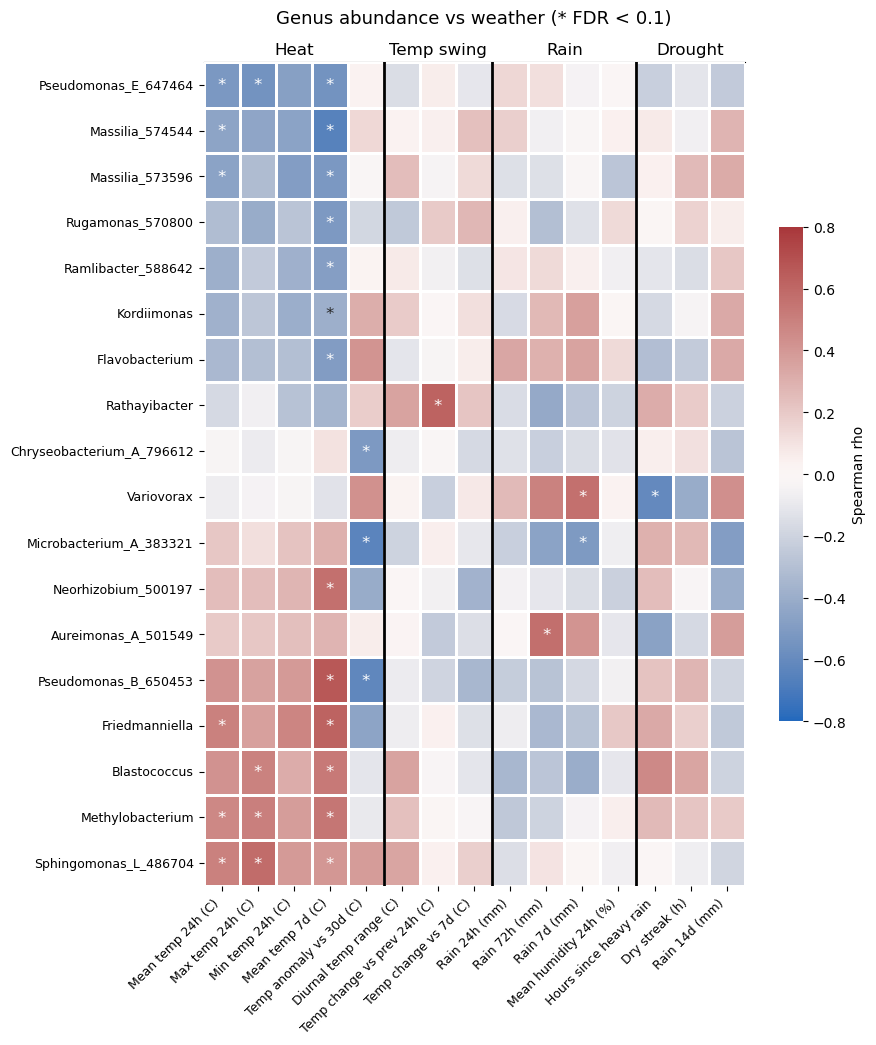

In [20]:
# Correlation map: every genus with at least one FDR < 0.1 hit, across all weather variables.
heatmap_genera = (
    genus_weather_corr.loc[genus_weather_corr["q"] < 0.1, "genus"].unique().tolist()
)
rho_matrix = genus_weather_corr.pivot(
    index="genus", columns="variable", values="rho"
).loc[heatmap_genera, weather_variable_list]
q_matrix = genus_weather_corr.pivot(index="genus", columns="variable", values="q").loc[
    heatmap_genera, weather_variable_list
]
# Order genera cold-associated -> warm-associated for readability.
rho_matrix = rho_matrix.loc[rho_matrix[weather_variables["Heat"]].mean(axis=1).sort_values().index]
q_matrix = q_matrix.loc[rho_matrix.index]
significance_stars = q_matrix.map(lambda q: "*" if q < 0.1 else "")

fig, ax = plt.subplots(figsize=(9, 0.42 * len(rho_matrix) + 3))
fig.patch.set_facecolor("white")
sns.heatmap(
    rho_matrix,
    cmap="vlag",
    center=0,
    vmin=-0.8,
    vmax=0.8,
    linewidths=2,
    linecolor="white",
    annot=significance_stars,
    fmt="",
    annot_kws={"fontsize": 12},
    cbar_kws={"label": "Spearman rho", "shrink": 0.6},
    ax=ax,
)

# Divider lines and headers for the four weather categories.
boundary = 0
for variables in list(weather_variables.values())[:-1]:
    boundary += len(variables)
    ax.axvline(boundary, color="black", linewidth=2)
group_centers, boundary = [], 0
for group, variables in weather_variables.items():
    group_centers.append((boundary + len(variables) / 2, group))
    boundary += len(variables)
category_axis = ax.secondary_xaxis("top")
category_axis.set_xticks([center for center, _ in group_centers])
category_axis.set_xticklabels([group for _, group in group_centers], fontsize=12)
category_axis.tick_params(length=0)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Genus abundance vs weather (* FDR < 0.1)", fontsize=13, pad=28)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
plt.setp(ax.get_yticklabels(), fontsize=9)
plt.tight_layout()
plt.show()

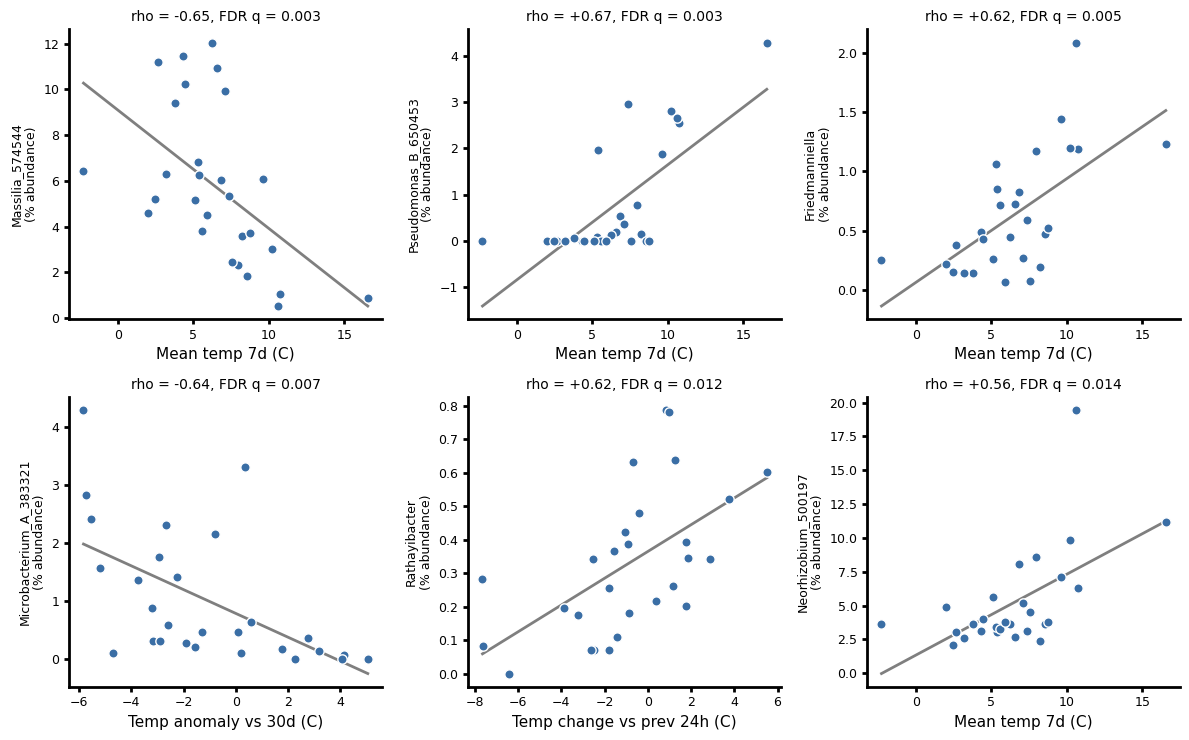

In [21]:
# The strongest hit for each of the top genera, plotted as raw abundance vs weather.
top_hits = significant_hits.drop_duplicates(subset="genus").head(6)

fig, axes = plt.subplots(2, 3, figsize=(12, 7.5))
fig.patch.set_facecolor("white")
for ax, (_, hit) in zip(axes.flat, top_hits.iterrows()):
    x = weather_features[hit["variable"]]
    y = genus_by_timepoint[hit["genus"]]
    ax.scatter(x, y, s=45, color="#3a6ea5", edgecolor="white", linewidth=1, zorder=3)
    slope, intercept = np.polyfit(x, y, 1)  # visual guide only; the test is rank-based
    line_x = np.linspace(x.min(), x.max(), 10)
    ax.plot(line_x, slope * line_x + intercept, color="black", linewidth=2, alpha=0.5, zorder=2)
    ax.set_xlabel(hit["variable"], fontsize=11)
    ax.set_ylabel(f"{hit['genus']}\n(% abundance)", fontsize=9)
    ax.set_title(f"rho = {hit['rho']:+.2f}, FDR q = {hit['q']:.3f}", fontsize=10)
    sns.despine(ax=ax)
    for side in ("bottom", "left"):
        ax.spines[side].set_color("black")
        ax.spines[side].set_linewidth(2)
    ax.tick_params(axis="both", width=2, labelsize=9)
for ax in axes.flat[len(top_hits) :]:
    ax.remove()
plt.tight_layout()
plt.show()

### Reading these results

On the current data the signal is dominated by **heat**, with a clear split in the
phyllosphere: *Sphingomonas*, *Methylobacterium*, *Blastococcus*, *Friedmanniella*,
*Neorhizobium* and *Pseudomonas_B* rise with warmer 24h/7d temperatures, while
*Massilia*, *Pseudomonas_E*, *Rugamonas*, *Ramlibacter* and *Flavobacterium* fall.
Outside heat, three hits are worth following up: *Rathayibacter* tracks the
**24h temperature swing** (rho ~ +0.63), *Aureimonas* tracks **72h rainfall**, and
*Variovorax* is high right after rain and decays with **hours since heavy rain** and
across a **dry streak** - the only genus here that reads as a drought/wetness responder
rather than a temperature responder.

Caveats to keep in mind before treating any of these as causal:

- **Season is the main confounder.** Only the season-adjusted column is safe to quote for
  slow-moving variables like 7-day mean temperature; `Temp anomaly vs 30d` is itself
  strongly correlated with day-of-experiment (see the seasonality table), which is why its
  hits mostly evaporate after adjustment.
- **The circular-shift test is conservative and coarse** - its floor is p ~ 0.036 with 28
  timepoints, so it can only ever flag the very strongest associations. Read it as a filter,
  not as a p-value to report.
- **Weather variables are collinear** (max/mean/min temp; rain at 24h/72h/7d). A genus lighting
  up in several columns of the same block is one association, not several. The FDR is computed
  within each variable, so it does not correct across the 15 columns.
- **Abundances are compositional.** Renormalized percentages force genera to trade off against
  each other, so a rise in a dominant genus like *Sphingomonas* (~29% mean) mechanically pushes
  the rest down. A CLR or ALR transform, or a differential-abundance model that respects the
  compositional structure, would firm this up.
- **This window is Nov -> Mar**, not a full year, and true heat/drought extremes are outside it;
  "heat" here means ~17C, not summer.

## Sunshine

Meteostat's sunshine-duration channel (`tsun`) is empty for this location, so sunshine is
derived from the hourly condition code (`coco`: 1 = clear, 2 = fair) restricted to daylight
hours, with daylight determined from solar elevation. That gives a clear-sky *fraction of
daylight hours* rather than an irradiance measurement - it separates sunny from overcast,
but not a bright winter day from a bright spring one.



In [ ]:
# Sunshine features: clear-sky fraction of daylight hours in the windows before sampling.
LATITUDE, LONGITUDE = 40.73005, -73.99450


def solar_elevation(times_utc, latitude=LATITUDE, longitude=LONGITUDE):
    """Solar elevation in degrees (NOAA approximation) for UTC timestamps."""
    times_utc = pd.DatetimeIndex(times_utc)
    day_of_year = times_utc.dayofyear.values
    hour = times_utc.hour.values + times_utc.minute.values / 60
    gamma = 2 * np.pi / 365 * (day_of_year - 1 + (hour - 12) / 24)
    eq_time = 229.18 * (
        0.000075
        + 0.001868 * np.cos(gamma)
        - 0.032077 * np.sin(gamma)
        - 0.014615 * np.cos(2 * gamma)
        - 0.040849 * np.sin(2 * gamma)
    )
    declination = (
        0.006918
        - 0.399912 * np.cos(gamma)
        + 0.070257 * np.sin(gamma)
        - 0.006758 * np.cos(2 * gamma)
        + 0.000907 * np.sin(2 * gamma)
        - 0.002697 * np.cos(3 * gamma)
        + 0.00148 * np.sin(3 * gamma)
    )
    true_solar_time = (hour * 60 + eq_time + 4 * longitude) % 1440
    hour_angle = np.deg2rad(true_solar_time / 4 - 180)
    latitude_rad = np.deg2rad(latitude)
    elevation = np.arcsin(
        np.sin(latitude_rad) * np.sin(declination)
        + np.cos(latitude_rad) * np.cos(declination) * np.cos(hour_angle)
    )
    return np.rad2deg(elevation)


weather_hourly["is_daylight"] = solar_elevation(weather_hourly.index) > 0
# coco 1 = clear, 2 = fair; anything else during daylight counts as not sunny.
weather_hourly["is_sunny"] = weather_hourly["is_daylight"] & weather_hourly["coco"].isin([1, 2])

# Meteostat is UTC, sampling times are local - convert before windowing.
sample_times_utc = (
    timepoint_times["Date and Time"]
    .dt.tz_localize("America/New_York")
    .dt.tz_convert("UTC")
    .dt.tz_localize(None)
)


def sunny_fraction(window):
    """Share of the window's daylight hours that were clear or fair."""
    daylight_hours = window["is_daylight"].sum()
    return window["is_sunny"].sum() / daylight_hours if daylight_hours else np.nan


sun_rows = []
for timepoint, sample_time in sample_times_utc.items():
    last_24h = weather_window(sample_time, 24)
    last_72h = weather_window(sample_time, 72)
    last_7d = weather_window(sample_time, 24 * 7)

    sunny_before = weather_hourly.loc[
        (weather_hourly.index <= sample_time) & weather_hourly["is_sunny"]
    ]
    hours_since_sun = (
        (sample_time - sunny_before.index.max()).total_seconds() / 3600
        if len(sunny_before)
        else np.nan
    )

    sun_rows.append(
        {
            "timepoint": timepoint,
            "Sunny fraction 24h": sunny_fraction(last_24h),
            "Sunny fraction 72h": sunny_fraction(last_72h),
            "Sunny fraction 7d": sunny_fraction(last_7d),
            "Sunny hours 24h": last_24h["is_sunny"].sum(),
            "Hours since sunshine": hours_since_sun,
            # Photoperiod: reported for context, not tested (pure season proxy).
            "Daylight hours 24h": last_24h["is_daylight"].sum(),
        }
    )

sun_features = pd.DataFrame(sun_rows).set_index("timepoint")
sun_variables = [
    "Sunny fraction 24h",
    "Sunny fraction 72h",
    "Sunny fraction 7d",
    "Sunny hours 24h",
    "Hours since sunshine",
]

# What is sunshine standing in for? Sun is anti-correlated with humidity and rain, and
# positively correlated with the diurnal temperature range (clear nights radiate heat away).
sun_context = pd.DataFrame(
    {
        other: {
            sun_variable: scipy.stats.spearmanr(
                sun_features[sun_variable], series
            )[0]
            for sun_variable in sun_variables + ["Daylight hours 24h"]
        }
        for other, series in [
            ("day of experiment", timepoint_times["daysincestart"]),
            ("Mean humidity 24h (%)", weather_features["Mean humidity 24h (%)"]),
            ("Rain 24h (mm)", weather_features["Rain 24h (mm)"]),
            ("Rain 7d (mm)", weather_features["Rain 7d (mm)"]),
            ("Diurnal temp range (C)", weather_features["Diurnal temp range (C)"]),
            ("Mean temp 24h (C)", weather_features["Mean temp 24h (C)"]),
        ]
    }
)
print("Spearman rho of each sunshine variable with:")
print(sun_context.round(2).to_string())
sun_features.round(2)

In [ ]:
# Same test as for heat / swings / rain / drought: Spearman per genus, season-adjusted
# partial, circular-shift permutation, BH-FDR within each sunshine variable.
sun_correlation_rows = []
for genus in genera_to_test:
    abundance = genus_by_timepoint[genus].values
    for variable in sun_variables:
        sunshine = sun_features[variable].values
        rho, p = scipy.stats.spearmanr(sunshine, abundance)
        rho_season, p_season = partial_spearman(sunshine, abundance, days_since_start)
        sun_correlation_rows.append(
            {
                "genus": genus,
                "variable": variable,
                "rho": rho,
                "p": p,
                "rho season-adjusted": rho_season,
                "p season-adjusted": p_season,
                "p circular-shift": circular_shift_p(sunshine, abundance, rho),
                "mean abundance %": genus_mean_abundance[genus],
            }
        )

genus_sun_corr = pd.DataFrame(sun_correlation_rows)
for p_column, q_column in [("p", "q"), ("p season-adjusted", "q season-adjusted")]:
    genus_sun_corr[q_column] = genus_sun_corr.groupby("variable")[p_column].transform(
        lambda p: multipletests(p, method="fdr_bh")[1]
    )

sun_hits = genus_sun_corr.loc[genus_sun_corr["q"] < 0.1]
print(
    f"{len(sun_hits)} genus-sunshine pairs at FDR < 0.1 out of {len(genus_sun_corr)} tested; "
    f"{(genus_sun_corr['p'] < 0.05).sum()} are nominally significant before correction "
    f"({0.05 * len(genus_sun_corr):.0f} expected by chance)."
)
print("\nStrongest associations (uncorrected p, for follow-up only):")
genus_sun_corr.sort_values("p").head(10).round(3)

In [ ]:
# Sunshine correlation map for every tested genus. Nothing clears FDR, so cells are marked
# at the uncorrected p < 0.05 level - read these as candidates, not findings.
sun_rho_matrix = genus_sun_corr.pivot(index="genus", columns="variable", values="rho")[
    sun_variables
]
sun_p_matrix = genus_sun_corr.pivot(index="genus", columns="variable", values="p")[
    sun_variables
]
sun_rho_matrix = sun_rho_matrix.loc[
    sun_rho_matrix["Sunny fraction 7d"].sort_values().index
]
sun_p_matrix = sun_p_matrix.loc[sun_rho_matrix.index]
nominal_marks = sun_p_matrix.map(lambda p: "\u00b7" if p < 0.05 else "")

fig, axes = plt.subplots(
    1, 2, figsize=(14, 0.32 * len(sun_rho_matrix) + 3.5),
    gridspec_kw={"width_ratios": [1, 1.35]},
)
fig.patch.set_facecolor("white")

sns.heatmap(
    sun_rho_matrix,
    cmap="vlag",
    center=0,
    vmin=-0.8,
    vmax=0.8,
    linewidths=2,
    linecolor="white",
    annot=nominal_marks,
    fmt="",
    annot_kws={"fontsize": 16},
    cbar_kws={"label": "Spearman rho", "shrink": 0.5},
    ax=axes[0],
)
axes[0].set_xlabel("")
axes[0].set_ylabel("")
axes[0].set_title("Genus abundance vs sunshine\n(no FDR hits; \u00b7 = uncorrected p < 0.05)", fontsize=12)
plt.setp(axes[0].get_xticklabels(), rotation=45, ha="right", fontsize=9)
plt.setp(axes[0].get_yticklabels(), fontsize=8)

# The single strongest candidate, plotted raw.
top_sun_hit = genus_sun_corr.sort_values("p").iloc[0]
x = sun_features[top_sun_hit["variable"]]
y = genus_by_timepoint[top_sun_hit["genus"]]
axes[1].scatter(x, y, s=55, color="#c98a1f", edgecolor="white", linewidth=1, zorder=3)
slope, intercept = np.polyfit(x, y, 1)
line_x = np.linspace(x.min(), x.max(), 10)
axes[1].plot(line_x, slope * line_x + intercept, color="black", linewidth=2, alpha=0.5, zorder=2)
axes[1].set_xlabel(top_sun_hit["variable"], fontsize=12)
axes[1].set_ylabel(f"{top_sun_hit['genus']} (% abundance)", fontsize=11)
axes[1].set_title(
    f"rho = {top_sun_hit['rho']:+.2f}, p = {top_sun_hit['p']:.3f}, "
    f"FDR q = {top_sun_hit['q']:.2f}",
    fontsize=11,
)
sns.despine(ax=axes[1])
for side in ("bottom", "left"):
    axes[1].spines[side].set_color("black")
    axes[1].spines[side].set_linewidth(2)
axes[1].tick_params(axis="both", width=2, labelsize=10)

plt.tight_layout()
plt.show()

### Sunshine: no genus-level signal that survives correction

**Nothing clears FDR < 0.1 against any sunshine variable**, in contrast to temperature
(where ~30 pairs do). Sunshine also barely tracks day-of-experiment (|rho| <= 0.17), so this
is not the seasonal confound hiding a real effect - the associations simply are not there at
this sample size.

The one candidate worth carrying forward is *Rathayibacter*, which rises with the sunny
fraction over the previous 72h (rho = +0.51, uncorrected p = 0.006, q = 0.19). That is very
likely the same signal as its temperature-swing association above: clear skies produce a
larger diurnal temperature range (rho = +0.49 between the two), and when each is adjusted for
the other, the temperature swing holds up better (rho = +0.63, p = 0.0004) than sunshine does
(rho = +0.41, p = 0.034). *Rathayibacter* is a mean 0.3% of the community, so it is also the
kind of low-abundance genus where a handful of timepoints drives the correlation - check the
scatter before believing it.

Why a null here is plausible rather than merely underpowered: the sunshine measure is a
clear-sky *fraction*, not irradiance or UV dose, and it is measured Nov-Mar when the sun is
low. A summer window, or an actual pyranometer/UV index series, would be a much sharper test
of the light hypothesis.